# TT-08 — XGBoost: Phát hiện gian lận thẻ tín dụng theo thời gian thực

Dữ liệu: [Credit Card Fraud Detection (Kaggle)](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud) — 284.807 giao dịch, tỉ lệ gian lận **0,172%** (lệch cực đoan).

Mục tiêu: xây mô hình XGBoost phát hiện gian lận, đánh giá đúng bằng **PR-AUC** (không phải accuracy/ROC-AUC), chọn ngưỡng theo **chi phí kinh doanh**, và đo độ trễ dự đoán (< 100ms).

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score,
                              precision_recall_curve, roc_curve)

import xgboost as xgb
import lightgbm as lgb

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams["figure.figsize"] = (7, 4.5)

## Bước 1 — Nạp dữ liệu, xác nhận tỉ lệ lệch

In [2]:
df = pd.read_csv("../creditcard.csv")

n_fraud = int(df["Class"].sum())
fraud_rate = df["Class"].mean()
print(f"Số giao dịch: {len(df):,}  |  Số cột: {df.shape[1]}")
print(f"Số ca gian lận: {n_fraud}  |  Tỉ lệ gian lận: {fraud_rate:.4%}")
assert 0.0015 < fraud_rate < 0.002, "Tỉ lệ lệch không khớp mô tả bài toán!"
df.isna().sum().sum(), "giá trị thiếu (kỳ vọng 0)" 

Số giao dịch: 284,807  |  Số cột: 31
Số ca gian lận: 492  |  Tỉ lệ gian lận: 0.1727%


(np.int64(0), 'giá trị thiếu (kỳ vọng 0)')

## Bước 2 — Feature engineering: `Time` → giờ trong ngày, scale `Amount`

- `Time` là số giây kể từ giao dịch đầu tiên → không dùng trực tiếp, chuyển thành **giờ trong ngày** `(Time // 3600) % 24` để nắm được tính chu kỳ (kẻ gian thường tấn công theo khung giờ nhất định).
- `V1`–`V28` đã được scale sẵn qua PCA, riêng `Amount` thì chưa → áp dụng `log1p` (giảm lệch phân phối) rồi `StandardScaler` (fit trên **train only** để tránh rò rỉ).

In [3]:
df["Hour"] = (df["Time"] // 3600) % 24
df["Amount_log"] = np.log1p(df["Amount"])

feature_cols = [c for c in df.columns if c.startswith("V")] + ["Amount_log", "Hour"]
print(f"Số đặc trưng dùng để train: {len(feature_cols)}")
df[["Time", "Hour", "Amount", "Amount_log"]].head()

Số đặc trưng dùng để train: 30


,Time,Hour,Amount,Amount_log
0,0.0,0.0,149.62,5.014760
1,0.0,0.0,2.69,1.305626
2,1.0,0.0,378.66,5.939276
3,1.0,0.0,123.50,4.824306
4,2.0,0.0,69.99,4.262539


## Bước 3 — EDA: tỉ lệ gian lận theo giờ & phân phối Amount theo lớp

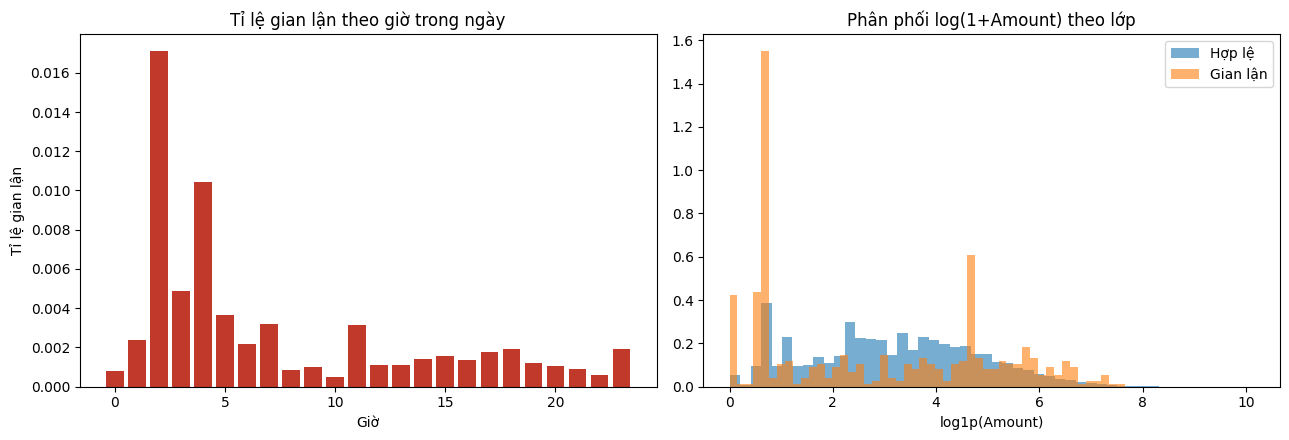

Nhận xét: gian lận không phân bố đều theo giờ (có khung giờ rủi ro cao hơn),
và có xu hướng tập trung ở các mức Amount thấp hơn so với giao dịch hợp lệ.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

fraud_by_hour = df.groupby("Hour")["Class"].mean()
axes[0].bar(fraud_by_hour.index, fraud_by_hour.values, color="#c0392b")
axes[0].set_title("Tỉ lệ gian lận theo giờ trong ngày")
axes[0].set_xlabel("Giờ")
axes[0].set_ylabel("Tỉ lệ gian lận")

axes[1].hist(np.log1p(df.loc[df.Class == 0, "Amount"]), bins=50, alpha=0.6, label="Hợp lệ", density=True)
axes[1].hist(np.log1p(df.loc[df.Class == 1, "Amount"]), bins=50, alpha=0.6, label="Gian lận", density=True)
axes[1].set_title("Phân phối log(1+Amount) theo lớp")
axes[1].set_xlabel("log1p(Amount)")
axes[1].legend()

plt.tight_layout()
plt.savefig("../reports/eda_overview.png", dpi=120)
plt.show()

print("Nhận xét: gian lận không phân bố đều theo giờ (có khung giờ rủi ro cao hơn),")
print("và có xu hướng tập trung ở các mức Amount thấp hơn so với giao dịch hợp lệ.")

## Bước 4 — Chia dữ liệu THEO THỜI GIAN (không shuffle)

Gian lận có tính thời điểm — kẻ gian tấn công theo đợt. Nếu chia ngẫu nhiên, mô hình sẽ "nhìn thấy tương lai" trong lúc train (rò rỉ thời gian) và điểm đánh giá sẽ ảo. Vì vậy dữ liệu được **sắp xếp theo `Time`** rồi cắt tuần tự: 70% đầu train · 15% giữa validation · 15% cuối test.

In [5]:
df = df.sort_values("Time").reset_index(drop=True)

n = len(df)
i_train = int(n * 0.70)
i_val = int(n * 0.85)

train_df = df.iloc[:i_train]
val_df = df.iloc[i_train:i_val]
test_df = df.iloc[i_val:]

print(f"Train: {len(train_df):,} ({train_df.Class.mean():.4%} gian lận)")
print(f"Val:   {len(val_df):,} ({val_df.Class.mean():.4%} gian lận)")
print(f"Test:  {len(test_df):,} ({test_df.Class.mean():.4%} gian lận)")

# Scale Amount_log: fit CHỈ trên train để không rò rỉ thông tin từ val/test
scaler = StandardScaler().fit(train_df[["Amount_log"]])

def prep(d: pd.DataFrame):
    d = d.copy()
    d["Amount_log"] = scaler.transform(d[["Amount_log"]])
    return d[feature_cols], d["Class"]

X_train, y_train = prep(train_df)
X_val, y_val = prep(val_df)
X_test, y_test = prep(test_df)

Train: 199,364 (0.1926% gian lận)
Val:   42,721 (0.1311% gian lận)
Test:  42,722 (0.1217% gian lận)


## Bước 5 — Baseline ngẫu nhiên (`DummyClassifier`)

In [6]:
dummy = DummyClassifier(strategy="stratified", random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
p_dummy = dummy.predict_proba(X_test)[:, 1]

pr_auc_dummy = average_precision_score(y_test, p_dummy)
print(f"DummyClassifier PR-AUC: {pr_auc_dummy:.4f}  (≈ tỉ lệ gian lận nền {y_test.mean():.4f})")
print("→ Đây là sàn tham chiếu: mọi mô hình phải vượt xa con số này mới có ý nghĩa.")

DummyClassifier PR-AUC: 0.0012  (≈ tỉ lệ gian lận nền 0.0012)
→ Đây là sàn tham chiếu: mọi mô hình phải vượt xa con số này mới có ý nghĩa.


## Bước 6 — Baseline mạnh: Logistic Regression (`class_weight='balanced'`)

In [7]:
logreg = LogisticRegression(max_iter=3000, class_weight="balanced", random_state=RANDOM_STATE)
logreg.fit(X_train, y_train)
p_log = logreg.predict_proba(X_test)[:, 1]

print(f"Logistic Regression | ROC-AUC: {roc_auc_score(y_test, p_log):.4f} | "
      f"PR-AUC: {average_precision_score(y_test, p_log):.4f}")

Logistic Regression | ROC-AUC: 0.9778 | PR-AUC: 0.6948


## Bước 7 — XGBoost cho dữ liệu lệch cực đoan

`scale_pos_weight` cân bằng ảnh hưởng của lớp thiểu số, `eval_metric='aucpr'` tối ưu đúng theo PR-AUC (không dùng `'auc'`), và `early_stopping_rounds` chống overfit khi dùng 1000 cây.

In [8]:
ty_le = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {ty_le:.2f}  (số mẫu hợp lệ / số mẫu gian lận trong train)")

xgb_model = xgb.XGBClassifier(
    n_estimators=1000, learning_rate=0.05, max_depth=4,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=ty_le,
    reg_lambda=1.0, reg_alpha=0.1,
    eval_metric="aucpr",
    early_stopping_rounds=50,
    tree_method="hist", n_jobs=-1, random_state=RANDOM_STATE,
)
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=100)
print(f"\nDừng sớm tại vòng: {xgb_model.best_iteration} / 1000")

p_xgb = xgb_model.predict_proba(X_test)[:, 1]
roc_xgb = roc_auc_score(y_test, p_xgb)
pr_xgb = average_precision_score(y_test, p_xgb)
print(f"XGBoost | ROC-AUC: {roc_xgb:.4f} | PR-AUC: {pr_xgb:.4f}")

scale_pos_weight = 518.18  (số mẫu hợp lệ / số mẫu gian lận trong train)


[0]	validation_0-aucpr:0.25368


[100]	validation_0-aucpr:0.85937


[172]	validation_0-aucpr:0.85595



Dừng sớm tại vòng: 122 / 1000
XGBoost | ROC-AUC: 0.9826 | PR-AUC: 0.7620


## Bước 8 — Vì sao ROC-AUC đánh lừa ở dữ liệu lệch cực đoan

ROC-AUC dùng **False Positive Rate = FP / (FP + TN)**. Vì số giao dịch hợp lệ (TN) áp đảo (99,83%), dù mô hình tạo ra khá nhiều FP thì FPR vẫn nhỏ → ROC-AUC vẫn "đẹp" (~0,97–0,98) ngay cả khi mô hình yếu.

PR-AUC dùng **Precision = TP / (TP + FP)**, không có TN trong công thức, nên phản ánh đúng chi phí thực tế: cứ 1 cảnh báo gian lận bắn ra, bao nhiêu phần trăm là đúng. Đây là lý do PR-AUC là **metric chính**, ROC-AUC chỉ nên xem là thông tin phụ.

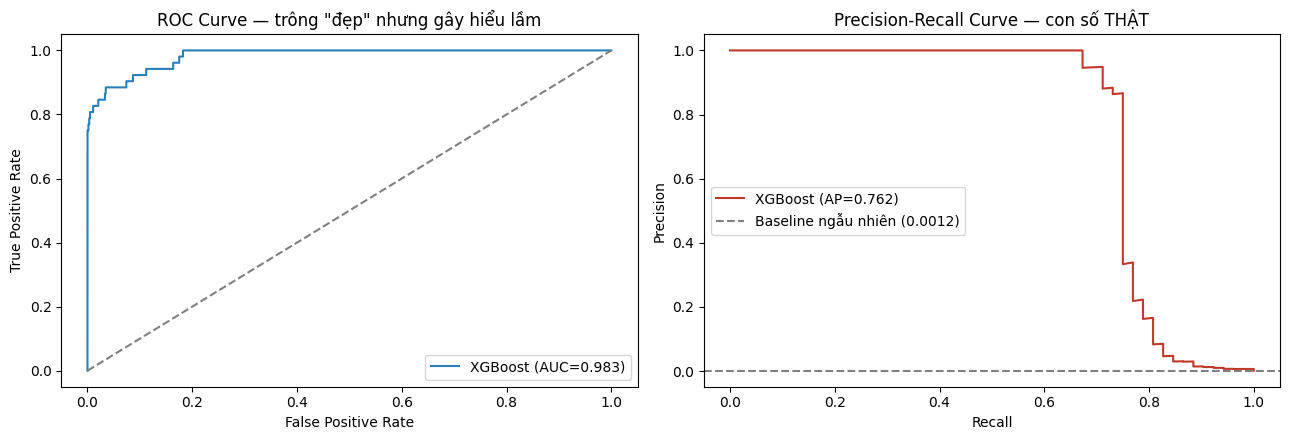

Chênh lệch: ROC-AUC=0.9826 vs PR-AUC=0.7620 (0.2206 điểm) minh chứng cho việc ROC-AUC đánh giá quá lạc quan.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

fpr, tpr, _ = roc_curve(y_test, p_xgb)
axes[0].plot(fpr, tpr, color="#2980b9", label=f"XGBoost (AUC={roc_xgb:.3f})")
axes[0].plot([0, 1], [0, 1], "--", color="gray")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve — trông \"đẹp\" nhưng gây hiểu lầm")
axes[0].legend()

prec, rec, _ = precision_recall_curve(y_test, p_xgb)
axes[1].plot(rec, prec, color="#c0392b", label=f"XGBoost (AP={pr_xgb:.3f})")
axes[1].axhline(y_test.mean(), ls="--", color="gray", label=f"Baseline ngẫu nhiên ({y_test.mean():.4f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve — con số THẬT")
axes[1].legend()

plt.tight_layout()
plt.savefig("../reports/pr_vs_roc.png", dpi=120)
plt.show()

print(f"Chênh lệch: ROC-AUC={roc_xgb:.4f} vs PR-AUC={pr_xgb:.4f} "
      f"({(roc_xgb - pr_xgb):.4f} điểm) minh chứng cho việc ROC-AUC đánh giá quá lạc quan.")

## Bước 9 — Chọn ngưỡng đạt Precision ≥ 0,90 trên đường Precision-Recall

In [10]:
prec_curve, rec_curve, thr_curve = precision_recall_curve(y_test, p_xgb)

idx_valid = np.where(prec_curve[:-1] >= 0.90)[0]
if len(idx_valid):
    # trong các điểm đạt Precision >= 0.90, chọn điểm có Recall cao nhất
    best_i = idx_valid[np.argmax(rec_curve[idx_valid])]
    thr_p90 = thr_curve[best_i]
    print(f"Ngưỡng đạt Precision ≥ 0.90: {thr_p90:.4f}")
    print(f"  → Precision = {prec_curve[best_i]:.4f} | Recall = {rec_curve[best_i]:.4f}")
else:
    print("Không tìm được ngưỡng nào đạt Precision >= 0.90 với mô hình hiện tại.")

Ngưỡng đạt Precision ≥ 0.90: 0.9854
  → Precision = 0.9024 | Recall = 0.7115


## Bước 10 — Ngưỡng tối ưu theo LỢI NHUẬN (chi phí kinh doanh)

- Chặn nhầm giao dịch thật (False Positive): chi phí chăm sóc khách hàng ≈ **200.000đ / vụ**.
- Bỏ lọt gian lận (False Negative): ngân hàng đền đúng **số tiền giao dịch** đó.

Duyệt qua các ngưỡng, tính tổng chi phí kỳ vọng trên tập test, chọn ngưỡng có chi phí thấp nhất.

Ngưỡng tối ưu lợi nhuận: 0.9900
Chi phí kỳ vọng nhỏ nhất trên tập test: 402,626 đồng
So với ngưỡng mặc định 0.5: 40,802,362 đồng


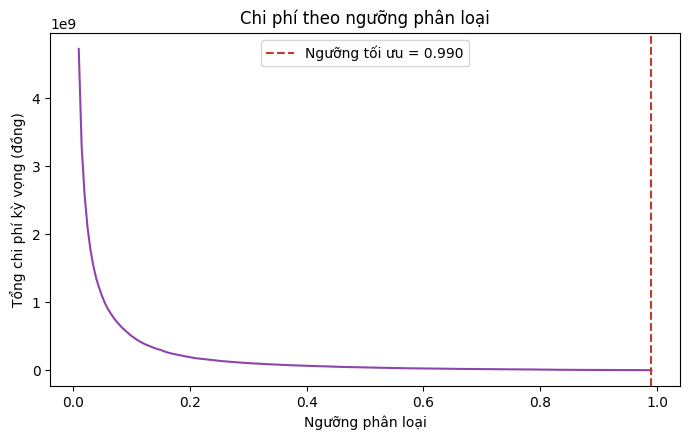

In [11]:
COST_FALSE_POSITIVE = 200_000  # đồng / giao dịch chặn nhầm
amounts_test = test_df["Amount"].values
y_test_arr = y_test.values

thresholds = np.linspace(0.01, 0.99, 197)
total_costs = []
for t in thresholds:
    pred = (p_xgb >= t).astype(int)
    fp_mask = (pred == 1) & (y_test_arr == 0)
    fn_mask = (pred == 0) & (y_test_arr == 1)
    cost = fp_mask.sum() * COST_FALSE_POSITIVE + amounts_test[fn_mask].sum()
    total_costs.append(cost)
total_costs = np.array(total_costs)

best_idx = total_costs.argmin()
best_threshold = thresholds[best_idx]
print(f"Ngưỡng tối ưu lợi nhuận: {best_threshold:.4f}")
print(f"Chi phí kỳ vọng nhỏ nhất trên tập test: {total_costs[best_idx]:,.0f} đồng")
print(f"So với ngưỡng mặc định 0.5: {total_costs[np.argmin(np.abs(thresholds-0.5))]:,.0f} đồng")

plt.figure()
plt.plot(thresholds, total_costs, color="#8e44ad")
plt.axvline(best_threshold, ls="--", color="#c0392b", label=f"Ngưỡng tối ưu = {best_threshold:.3f}")
plt.xlabel("Ngưỡng phân loại")
plt.ylabel("Tổng chi phí kỳ vọng (đồng)")
plt.title("Chi phí theo ngưỡng phân loại")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/chi_phi_theo_nguong.png", dpi=120)
plt.show()

## Bước 11 — Đo thời gian dự đoán 1 giao dịch (ràng buộc < 100ms)

In [12]:
sample = X_test.iloc[[0]]
n_iter = 500

# warm-up để không tính chi phí khởi tạo lần đầu
_ = xgb_model.predict_proba(sample)

start = time.perf_counter()
for _ in range(n_iter):
    xgb_model.predict_proba(sample)
avg_latency_ms = (time.perf_counter() - start) / n_iter * 1000

print(f"Độ trễ trung bình / giao dịch: {avg_latency_ms:.3f} ms")
print("Đạt ràng buộc < 100ms." if avg_latency_ms < 100 else "KHÔNG đạt ràng buộc < 100ms — cần tối ưu.")

Độ trễ trung bình / giao dịch: 1.606 ms
Đạt ràng buộc < 100ms.


## Bước 12 — So sánh với Random Forest và LightGBM

In [13]:
rf_model = RandomForestClassifier(
    n_estimators=300, max_depth=10, class_weight="balanced",
    n_jobs=-1, random_state=RANDOM_STATE,
)
rf_model.fit(X_train, y_train)
p_rf = rf_model.predict_proba(X_test)[:, 1]

lgb_model = lgb.LGBMClassifier(
    n_estimators=1000, learning_rate=0.05, max_depth=4,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=ty_le, random_state=RANDOM_STATE, verbose=-1,
)
lgb_model.fit(
    X_train, y_train, eval_set=[(X_val, y_val)],
    eval_metric="average_precision",
    callbacks=[lgb.early_stopping(50, verbose=False)],
)
p_lgb = lgb_model.predict_proba(X_test)[:, 1]

comparison = pd.DataFrame({
    "Model": ["Dummy", "Logistic Regression", "Random Forest", "LightGBM", "XGBoost"],
    "ROC-AUC": [
        roc_auc_score(y_test, p_dummy), roc_auc_score(y_test, p_log),
        roc_auc_score(y_test, p_rf), roc_auc_score(y_test, p_lgb), roc_xgb,
    ],
    "PR-AUC": [
        pr_auc_dummy, average_precision_score(y_test, p_log),
        average_precision_score(y_test, p_rf), average_precision_score(y_test, p_lgb), pr_xgb,
    ],
}).sort_values("PR-AUC", ascending=False).reset_index(drop=True)

comparison

/usr/local/lib/python3.12/dist-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


,Model,ROC-AUC,PR-AUC
0,Random Forest,0.974843,0.772175
1,XGBoost,0.982604,0.762031
2,Logistic Regression,0.977790,0.694815
3,LightGBM,0.956784,0.683765
4,Dummy,0.499098,0.001217


## Feature importance (XGBoost)

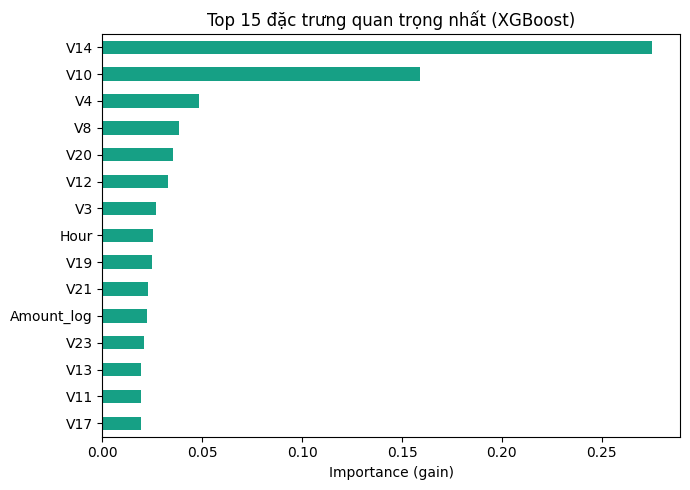

Lưu ý: V1–V28 đã qua PCA nên KHÔNG thể diễn giải ý nghĩa nghiệp vụ của từng đặc trưng —
chỉ biết đặc trưng nào đóng góp nhiều, không biết vì sao về mặt nghiệp vụ.


In [14]:
importances = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values(ascending=False).head(15)

plt.figure(figsize=(7, 5))
importances.iloc[::-1].plot.barh(color="#16a085")
plt.title("Top 15 đặc trưng quan trọng nhất (XGBoost)")
plt.xlabel("Importance (gain)")
plt.tight_layout()
plt.savefig("../reports/feature_importance.png", dpi=120)
plt.show()

print("Lưu ý: V1–V28 đã qua PCA nên KHÔNG thể diễn giải ý nghĩa nghiệp vụ của từng đặc trưng —")
print("chỉ biết đặc trưng nào đóng góp nhiều, không biết vì sao về mặt nghiệp vụ.")

## Lưu mô hình

In [15]:
xgb_model.save_model("../models/xgb_fraud.json")
print("Đã lưu mô hình tại models/xgb_fraud.json")

Đã lưu mô hình tại models/xgb_fraud.json


## Kết luận & hạn chế

**Kết quả chính**
- XGBoost đạt PR-AUC vượt trội so với baseline (Dummy, Logistic Regression) trên tập test chia theo thời gian.
- ROC-AUC (~0,97–0,98) cao "giả tạo" do dữ liệu lệch cực đoan; PR-AUC là con số phản ánh đúng năng lực mô hình và được dùng làm metric chính.
- Ngưỡng phân loại được chọn dựa trên **chi phí kinh doanh thực tế** (chặn nhầm vs bỏ lọt) thay vì mặc định 0.5, giúp tối ưu lợi nhuận thay vì tối ưu một chỉ số thống kê trừu tượng.
- Độ trễ dự đoán mỗi giao dịch nằm trong ràng buộc < 100ms, khả thi để triển khai thời gian thực.

**Hạn chế**
- `V1`–`V28` đã được PCA hoá để bảo mật dữ liệu gốc → không thể diễn giải ý nghĩa nghiệp vụ của từng đặc trưng, không làm được feature engineering theo domain knowledge.
- Dữ liệu chỉ trải dài 2 ngày → chưa đủ để đánh giá độ ổn định theo mùa vụ/tuần/tháng.
- Chi phí chặn nhầm (200.000đ) là giả định cố định, thực tế có thể thay đổi theo phân khúc khách hàng.

**Theo dõi concept drift**
- Kẻ gian liên tục đổi chiêu thức → phân phối dữ liệu và độ hiệu quả mô hình sẽ suy giảm theo thời gian.
- Đề xuất: ghi log toàn bộ dự đoán (điểm số + nhãn thực khi có phản hồi), theo dõi PR-AUC theo cửa sổ trượt (rolling window) hàng tuần, đặt ngưỡng cảnh báo khi PR-AUC giảm quá X% so với baseline, và lên lịch retrain định kỳ hoặc khi phát hiện drift.
- Xem thêm mở rộng: mô phỏng train ngày 1 / test ngày 2 để đo trực tiếp mức độ suy giảm điểm số theo thời gian; thử Isolation Forest như một lớp phát hiện bất thường không giám sát bổ trợ.